# Fase Base: Modelamiento de Dinámica de Poblaciones
**Grupo:** Barria-Olguin-Diaz-Pereira

**Descripción:** En este notebook implementamos los modelos de Malthus y Logístico para analizar el crecimiento poblacional.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Configuramos los gráficos para que se vean bien
plt.rcParams['figure.figsize'] = [10, 6]

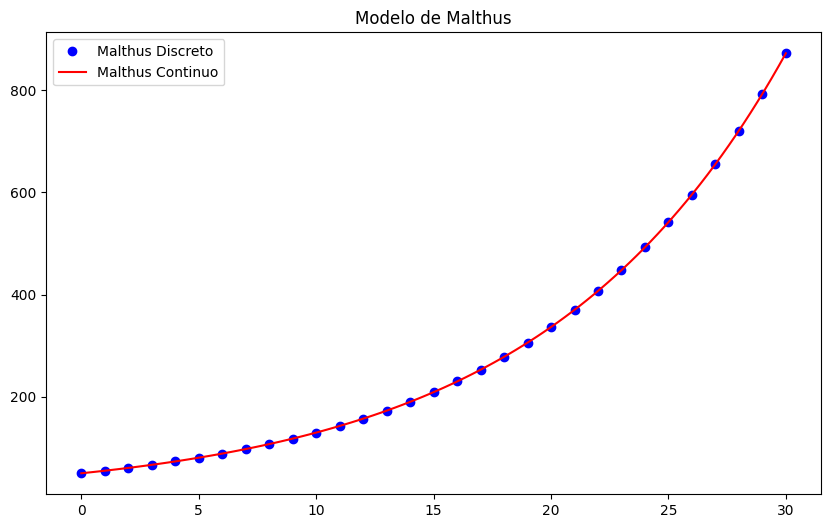

In [3]:
# Parámetros
X0 = 50       # Población inicial
r = 1.1       # Tasa de crecimiento
t_final = 30  # Tiempo total

# --- Malthus Discreto ---
t_discreto = np.arange(t_final + 1)
X_discreto = np.zeros(t_final + 1)
X_discreto[0] = X0
for n in range(t_final):
    X_discreto[n+1] = r * X_discreto[n]

# --- Malthus Continuo ---
alpha = np.log(r)
t_continuo = np.linspace(0, t_final, 100)
X_continuo = X0 * np.exp(alpha * t_continuo)

# Gráfico
plt.plot(t_discreto, X_discreto, 'bo', label='Malthus Discreto')
plt.plot(t_continuo, X_continuo, 'r-', label='Malthus Continuo')
plt.title("Modelo de Malthus")
plt.legend()
plt.show()

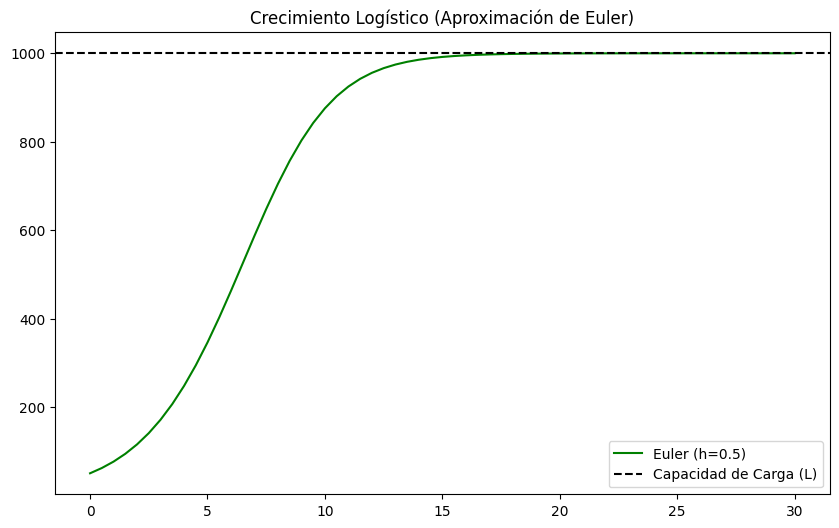

In [4]:
# Parámetros logísticos
L = 1000      # Capacidad máxima
rho = 0.0005  # Tasa de crecimiento intrínseca
X0 = 50
h = 0.5       # Tamaño de paso para Euler

# --- Método de Euler ---
pasos = int(t_final / h)
t_euler = np.linspace(0, t_final, pasos + 1)
X_euler = np.zeros(pasos + 1)
X_euler[0] = X0

for i in range(pasos):
    # La pendiente dX/dt = rho * X * (L - X)
    pendiente = rho * X_euler[i] * (L - X_euler[i])
    X_euler[i+1] = X_euler[i] + h * pendiente

# Gráfico de la Logística
plt.plot(t_euler, X_euler, 'g-', label=f'Euler (h={h})')
plt.axhline(y=L, color='k', linestyle='--', label='Capacidad de Carga (L)')
plt.title("Crecimiento Logístico (Aproximación de Euler)")
plt.legend()
plt.show()

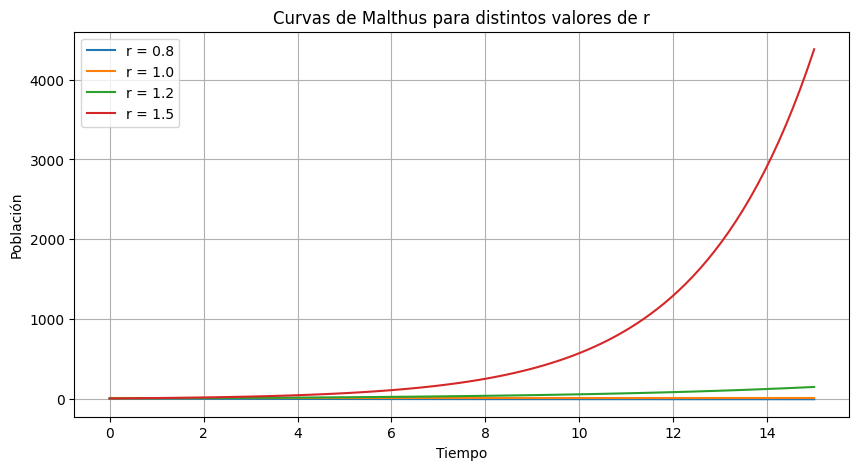

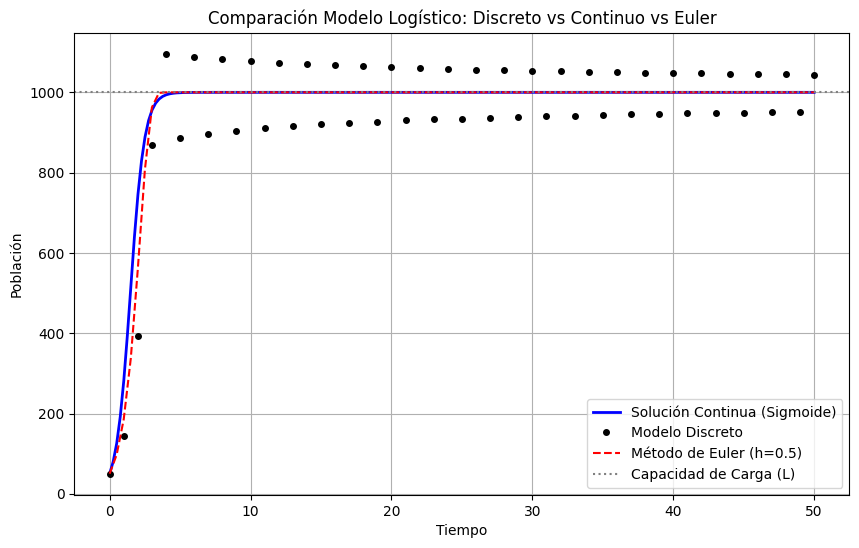

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# GRÁFICO 1: Malthus para distintos 'r' (Punto 4)
# ==========================================
plt.figure(figsize=(10, 5))
X0_malthus = 10
t_final_malthus = 15
t_continuo_m = np.linspace(0, t_final_malthus, 100)

# Lista con distintos valores de r para comparar
valores_r = [0.8, 1.0, 1.2, 1.5]

for r in valores_r:
    alpha = np.log(r)
    # Solución continua: X(t) = X0 * e^(alpha * t)
    X_continuo_m = X0_malthus * np.exp(alpha * t_continuo_m)
    plt.plot(t_continuo_m, X_continuo_m, label=f'r = {r}')

plt.title("Curvas de Malthus para distintos valores de r")
plt.xlabel("Tiempo")
plt.ylabel("Población")
plt.legend()
plt.grid(True)
plt.show()

# ==========================================
# PUNTO 3: Método de Euler para la EDO Logística
# ==========================================
L = 1000      # Capacidad de carga
rho = 0.002   # Tasa intrínseca
X0_log = 50   # Población inicial
T_final = 50  # Tiempo de simulación

# 1. Discreto: X_{n+1} = X_n + rho * X_n * (L - X_n)
t_discreto = np.arange(T_final + 1)
X_discreto = np.zeros(T_final + 1)
X_discreto[0] = X0_log
for n in range(T_final):
    X_discreto[n+1] = X_discreto[n] + rho * X_discreto[n] * (L - X_discreto[n])

# 2. Continuo Exacto (Sigmoide)
t_continuo = np.linspace(0, T_final, 200)
X_exacta = (L * X0_log) / (X0_log + (L - X0_log) * np.exp(-rho * L * t_continuo))

# 3. Método de Euler (con paso h = 0.5)
h = 0.5
pasos_euler = int(T_final / h)
t_euler = np.linspace(0, T_final, pasos_euler + 1)
X_euler = np.zeros(pasos_euler + 1)
X_euler[0] = X0_log

for i in range(pasos_euler):
    # La derivada de la logística: dX/dt = rho * X * (L - X)
    dX_dt = rho * X_euler[i] * (L - X_euler[i])
    X_euler[i+1] = X_euler[i] + h * dX_dt

# ==========================================
# GRÁFICO 2: Sigmoide Logística y Comparación (Punto 4)
# ==========================================
plt.figure(figsize=(10, 6))

# Trazamos la sigmoide exacta
plt.plot(t_continuo, X_exacta, 'b-', linewidth=2, label='Solución Continua (Sigmoide)')

# Trazamos el discreto (puntos)
plt.plot(t_discreto, X_discreto, 'ko', markersize=4, label='Modelo Discreto')

# Trazamos Euler
plt.plot(t_euler, X_euler, 'r--', label=f'Método de Euler (h={h})')

plt.axhline(y=L, color='gray', linestyle=':', label='Capacidad de Carga (L)')
plt.title("Comparación Modelo Logístico: Discreto vs Continuo vs Euler")
plt.xlabel("Tiempo")
plt.ylabel("Población")
plt.legend()
plt.grid(True)
plt.show()

###  Conclusiones y Análisis de Resultados

A partir de las implementaciones numéricas y los gráficos generados para la Fase Base, podemos concluir lo siguiente respecto al comportamiento de los parámetros fundamentales del modelo:

* **Efecto de la tasa de crecimiento ($r$) en el Modelo de Malthus:**
  Al variar el parámetro $r$ en el modelo discreto $X_{n+1}=rX_{n}$, observamos un cambio drástico en la concavidad y dirección de la curva.
  - Si $r > 1$, la población experimenta un crecimiento exponencial, y a medida que aumentamos el valor de $r$, la curva se vuelve mucho más empinada, alcanzando valores inmensos en menos tiempo.
  - Si $r = 1$, la población se mantiene constante a lo largo del tiempo.
  - Si $0 < r < 1$, la población decae exponencialmente hasta tender a la extinción (cero).
  Esto demuestra que el modelo de Malthus no es realista a largo plazo para poblaciones con $r > 1$, ya que asume recursos infinitos.

* **Efecto del tamaño de paso ($h$) en el Método de Euler:**
  El método de Euler es una aproximación numérica de la EDO logística. El parámetro $h$ representa el "salto temporal" entre cada cálculo.
  - Al **disminuir el valor de $h$** (por ejemplo, pasar de $h=1$ a $h=0,1$), la curva generada por el método de Euler se ajusta con mucha mayor precisión a la curva de la solución continua exacta (la sigmoide logística).
  - Esto ocurre porque al evaluar la pendiente de forma más seguida, se reduce el error de truncamiento acumulado en cada paso. Por el contrario, un $h$ demasiado grande genera un error visible, haciendo que la aproximación se separe de la curva real e incluso pueda generar oscilaciones irreales antes de estabilizarse en la capacidad de carga $L$.